In [155]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from torch_geometric.datasets import Planetoid

In [156]:
dataset = Planetoid(root="data", name="Cora")
data = dataset[0]
data

Data(x=[2708, 1433], edge_index=[2, 10556], y=[2708], train_mask=[2708], val_mask=[2708], test_mask=[2708])

In [157]:
print(f"Number of Nodes (Research paper) in dataset: {data.num_nodes}")
print(f"Number of Edges (Citations) in dataset: {data.num_edges}")
print(f"Number of Features per paper in dataset: {data.num_node_features}")
print(f"Number of Classes in dataset: {dataset.num_classes}")

print(f"Training papers: {data.train_mask.sum()}")
print(f"Testing papers: {data.test_mask.sum()}")
print(f"Validation papers: {data.val_mask.sum()}")

Number of Nodes (Research paper) in dataset: 2708
Number of Edges (Citations) in dataset: 10556
Number of Features per paper in dataset: 1433
Number of Classes in dataset: 7
Training papers: 140
Testing papers: 1000
Validation papers: 500


In [158]:
topic_counts = pd.Series(data.y.numpy()).value_counts().sort_index()

<Axes: xlabel='None', ylabel='count'>

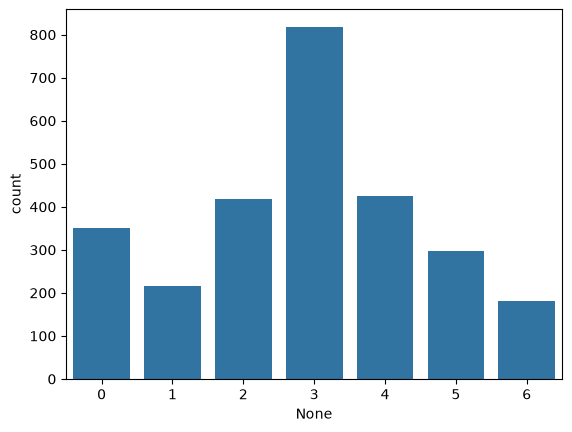

In [159]:
sns.barplot(x=topic_counts.index, y=topic_counts)

In [160]:
X_binary = data.x.numpy()
y = data.y.numpy()

In [161]:
import sklearn
from sklearn.feature_extraction.text import TfidfTransformer

tfidf = TfidfTransformer()
X_tfidf = tfidf.fit_transform(X_binary).toarray()
X_baseline = X_tfidf

In [162]:
train_idx = data.train_mask.numpy()
test_idx = data.test_mask.numpy()
val_idx = data.val_mask.numpy()

In [163]:
train_idx, test_idx, val_idx

(array([ True,  True,  True, ..., False, False, False], shape=(2708,)),
 array([False, False, False, ...,  True,  True,  True], shape=(2708,)),
 array([False, False, False, ..., False, False, False], shape=(2708,)))

In [164]:
X_train, y_train = X_baseline[train_idx], y[train_idx]
X_test, y_test = X_baseline[test_idx], y[test_idx]
X_val, y_val = X_baseline[val_idx], y[val_idx]

In [165]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    max_features="sqrt",
    random_state=42,
    n_jobs=-1,
    class_weight="balanced",
)

rf.fit(X_train, y_train)
rf_predictions = rf.predict(X_test)

In [166]:
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix

print(f"Accuracy of RF: {accuracy_score(y_test,rf_predictions):.4f}")
print(f"F1 score: {f1_score(y_test,rf_predictions,average="macro"):.4f}")

Accuracy of RF: 0.5780
F1 score: 0.5691


Hyperparameter tuning of RF

In [167]:
# from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

# rf_tuned = RandomForestClassifier(random_state=42, n_jobs=-1)

In [168]:
# param_grid = {
#     "n_estimators": [100, 200, 300],
#     "max_depth": [None, 5, 10, 20],
#     "min_samples_split": [2, 5, 10],
#     "min_samples_leaf": [1, 2, 4],
#     "max_features": ["sqrt", "log2", None],
# }

# grid_search = GridSearchCV(
#     estimator=rf,
#     param_grid=param_grid,
#     cv=5,
#     scoring="accuracy",
#     n_jobs=-1,
#     verbose=1,
# )

# grid_search.fit(X_train, y_train)

# print("Best params:", grid_search.best_params_)
# print("Best CV score:", grid_search.best_score_)

# best_rf = grid_search.best_estimator_
# y_pred = best_rf.predict(X_test)
# print("Test accuracy:", accuracy_score(y_test, y_pred))

In [169]:
# from scipy.stats import randint

# param_dist = {
#     "n_estimators": randint(100, 500),
#     "max_depth": randint(3, 30),  # or use [None, 5, 10, 20, 30]
#     "min_samples_split": randint(2, 20),
#     "min_samples_leaf": randint(1, 10),
#     "max_features": ["sqrt", "log2", None],
# }

# random_search = RandomizedSearchCV(
#     estimator=rf,
#     param_distributions=param_dist,
#     n_iter=50,  # number of random combinations to try
#     cv=5,
#     scoring="accuracy",
#     n_jobs=-1,
#     random_state=42,
#     verbose=1,
# )

# random_search.fit(X_train, y_train)

# print("Best params:", random_search.best_params_)
# print("Best CV score:", random_search.best_score_)

# best_rf = random_search.best_estimator_

<Axes: >

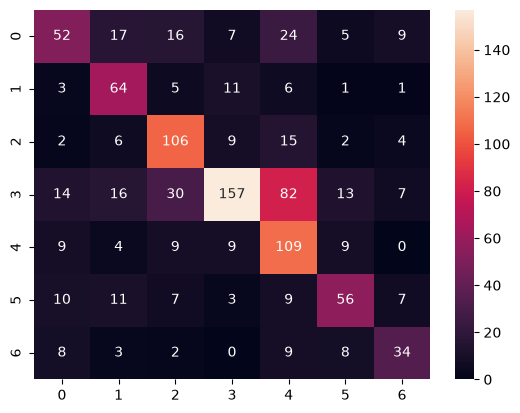

In [170]:
sns.heatmap(confusion_matrix(y_test, rf_predictions), annot=True, fmt="d")

GCN

In [171]:
import torch.nn.functional as F
from torch import nn
from torch_geometric.nn import GCNConv


class SimpleGCN(nn.Module):
    def __init__(self, in_dim, hidden_dim, out_dim, dropout=0.5):
        super().__init__()
        self.layer1 = GCNConv(in_dim, hidden_dim)
        self.layer2 = GCNConv(hidden_dim, out_dim)
        self.dropout = dropout

    def forward(self, x, idx):
        x = self.layer1(x, idx)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = self.layer2(x, idx)
        return x

In [172]:
model = SimpleGCN(
    in_dim=dataset.num_features, hidden_dim=32, out_dim=dataset.num_classes
)

In [173]:
model

SimpleGCN(
  (layer1): GCNConv(1433, 32)
  (layer2): GCNConv(32, 7)
)

In [174]:
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

Training of GCN Model

In [175]:
def train_one_epoch():
    model.train()
    optimizer.zero_grad()
    logits = model(data.x, data.edge_index)
    loss = F.cross_entropy(logits[data.train_mask], data.y[data.train_mask])
    loss.backward()
    optimizer.step()
    return loss.item()

In [176]:
@torch.no_grad()
def evaluate(mask):
    model.eval()
    logits = model(data.x, data.edge_index)
    predictions = logits[mask].argmax(dim=1)
    acc = (predictions == data.y[mask]).float().mean().item()
    f1 = f1_score(data.y[mask].numpy(), predictions.numpy(), average="macro")
    return acc, f1, predictions

Running some epochs

In [177]:
losses, train_acc, val_acc = [], [], []
best_val_acc = 0.0
best_state = None

for epoch in range(1, 201):
    loss = train_one_epoch()
    cur_train_acc, _, _ = evaluate(data.train_mask)
    cur_val_acc, _, _ = evaluate(data.val_mask)

    losses.append(loss)
    train_acc.append(cur_train_acc)
    val_acc.append(cur_val_acc)

    if cur_val_acc > best_val_acc:
        best_val_acc = cur_val_acc
        best_state = model.state_dict()

    if epoch == 1 or epoch % 10 == 0:
        print(
            f"Epoch: {epoch:03d} | Loss: {loss:.4f} | Train Acc: {cur_train_acc:.4f} | Validation Acc: {cur_val_acc:.4f} | Best Validation Acc: {best_val_acc:.4f}"
        )

Epoch: 001 | Loss: 1.9600 | Train Acc: 0.7643 | Validation Acc: 0.5800 | Best Validation Acc: 0.5800
Epoch: 010 | Loss: 0.4557 | Train Acc: 0.9857 | Validation Acc: 0.7720 | Best Validation Acc: 0.7760
Epoch: 020 | Loss: 0.0783 | Train Acc: 1.0000 | Validation Acc: 0.7780 | Best Validation Acc: 0.7920
Epoch: 030 | Loss: 0.0232 | Train Acc: 1.0000 | Validation Acc: 0.7820 | Best Validation Acc: 0.7920
Epoch: 040 | Loss: 0.0094 | Train Acc: 1.0000 | Validation Acc: 0.7780 | Best Validation Acc: 0.7920
Epoch: 050 | Loss: 0.0033 | Train Acc: 1.0000 | Validation Acc: 0.7820 | Best Validation Acc: 0.7920
Epoch: 060 | Loss: 0.0055 | Train Acc: 1.0000 | Validation Acc: 0.7840 | Best Validation Acc: 0.7920
Epoch: 070 | Loss: 0.0048 | Train Acc: 1.0000 | Validation Acc: 0.7840 | Best Validation Acc: 0.7920
Epoch: 080 | Loss: 0.0015 | Train Acc: 1.0000 | Validation Acc: 0.7780 | Best Validation Acc: 0.7920
Epoch: 090 | Loss: 0.0024 | Train Acc: 1.0000 | Validation Acc: 0.7780 | Best Validation Ac

In [178]:
model.load_state_dict(best_state)
gcn_acc, gcn_f1, gcn_predict = evaluate(data.test_mask)

In [180]:
print(f"GCN Acc: {gcn_acc:.4f} | GCN F1: {gcn_f1:.4f}")

GCN Acc: 0.7840 | GCN F1: 0.7783
